In [1]:
import sys
sys.path.insert(0, r'C:\Users\LENOVO\quant\src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data.loader import MarketDataLoader
from data.preprocessor import DataPreprocessor
from risk.metrics import RiskMetrics
from utils.visualization import FinancialVisualizer

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All modules loaded successfully")

✓ All modules loaded successfully


In [6]:
import yfinance as yf

ticker = 'AAPL'
print(f"Downloading {ticker}...")

data = yf.download(ticker, start='2023-01-01', end='2024-01-31', progress=False)

# Flatten MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(f"✓ Downloaded {len(data)} rows")
print(f"Columns: {data.columns.tolist()}")

# FIX: Create 'Adj Close' if it doesn't exist
if 'Adj Close' not in data.columns:
    print("\n⚠️  'Adj Close' not found - using 'Close' instead")
    data['Adj Close'] = data['Close']

print(f"\nFinal columns: {data.columns.tolist()}")
data.head()

✓ Downloaded 270 rows
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

⚠️  'Adj Close' not found - using 'Close' instead

Final columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close']


Price,Close,High,Low,Open,Volume,Adj Close
Date,,,,,,
2023-01-03,123.211212,128.954561,122.324586,128.343780,112117500,123.211212
2023-01-04,124.482040,126.747861,123.221065,125.004162,89113600,124.482040
2023-01-05,123.161934,125.871063,122.905803,125.240575,80962700,123.161934
2023-01-06,127.693550,128.353591,123.033853,124.137210,87754700,127.693550
2023-01-09,128.215698,131.427258,127.959568,128.530950,70790800,128.215698


In [7]:
preprocessor = DataPreprocessor()
missing_info = preprocessor.check_missing_data(data)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ No missing data")

quality_report = preprocessor.validate_data_quality(data)
print(f"Data valid: {quality_report['is_valid']}")

✓ No missing data
Data valid: True


In [8]:
prices = data['Adj Close']
rm = RiskMetrics()
log_returns = rm.log_returns(prices)

print(f"✓ Prices extracted: {len(prices)} values")
print(f"✓ Returns calculated: {len(log_returns)} values")
print(f"\nFirst 10 returns:\n{log_returns.head(10)}")

✓ Prices extracted: 270 values
✓ Returns calculated: 270 values

First 10 returns:
Date
2023-01-03         NaN
2023-01-04    0.010261
2023-01-05   -0.010661
2023-01-06    0.036133
2023-01-09    0.004081
2023-01-10    0.004446
2023-01-11    0.020893
2023-01-12   -0.000600
2023-01-13    0.010068
2023-01-17    0.008718
Name: Adj Close, dtype: float64


In [9]:
vol_21d = rm.rolling_volatility(log_returns, window=21)
realized_vol = rm.realized_volatility(log_returns)

print(f"Realized volatility: {realized_vol:.4f} ({100*realized_vol:.2f}%)")
print(f"Current 21-day vol: {vol_21d.iloc[-1]:.4f}")

Realized volatility: 0.2022 (20.22%)
Current 21-day vol: 0.2327


In [10]:
summary = rm.summary_statistics(prices, log_returns)
display(summary)

,Value
Start Date,2023-01-03 00:00:00
End Date,2024-01-30 00:00:00
Total Days,270
Start Price,123.211212
End Price,186.280807
Total Return (%),51.188195
Annualized Return (%),38.723238
Annualized Volatility (%),20.2244
Sharpe Ratio,1.914679
Max Drawdown (%),-14.932388


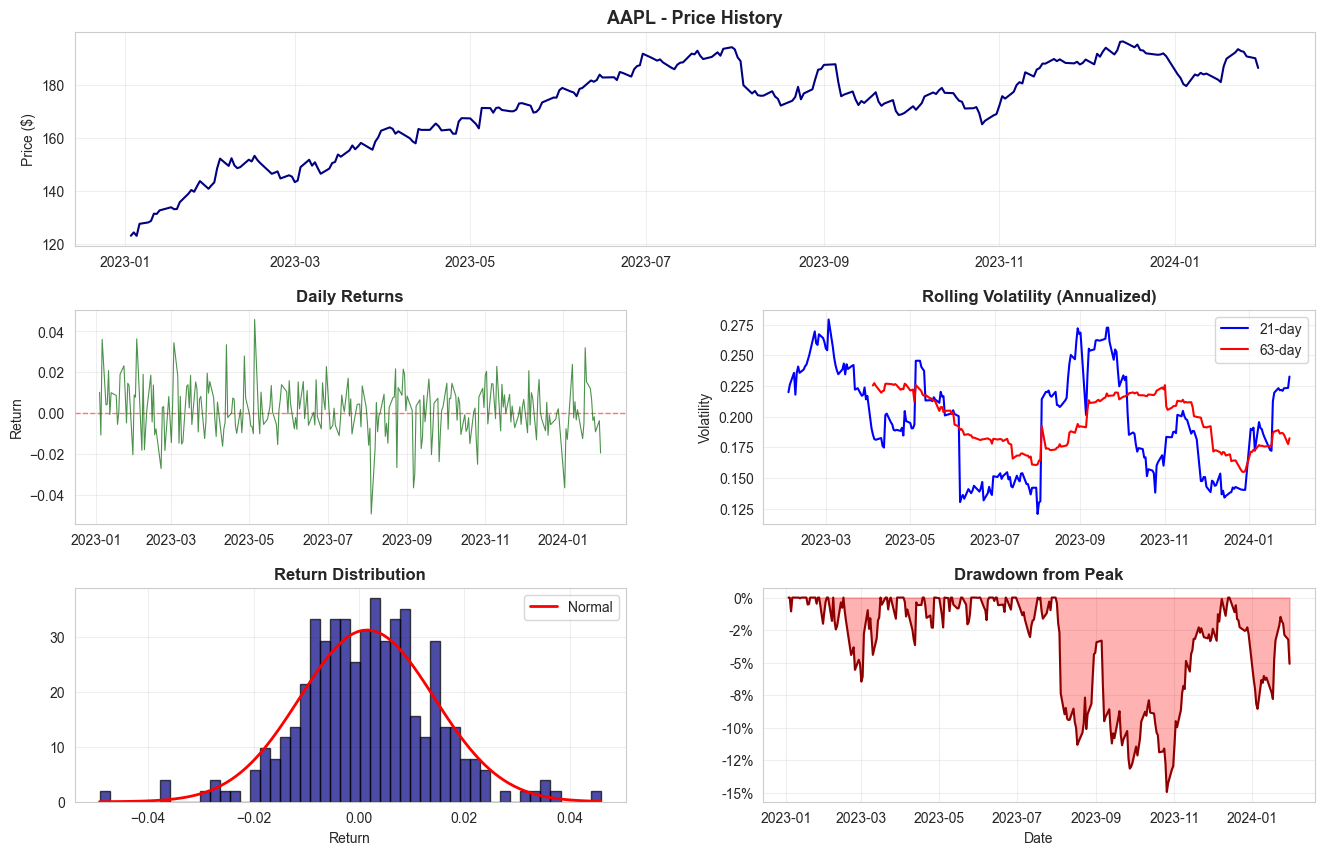

In [11]:
viz = FinancialVisualizer()
fig = viz.plot_comprehensive_analysis(prices, log_returns, ticker=ticker)
plt.show()

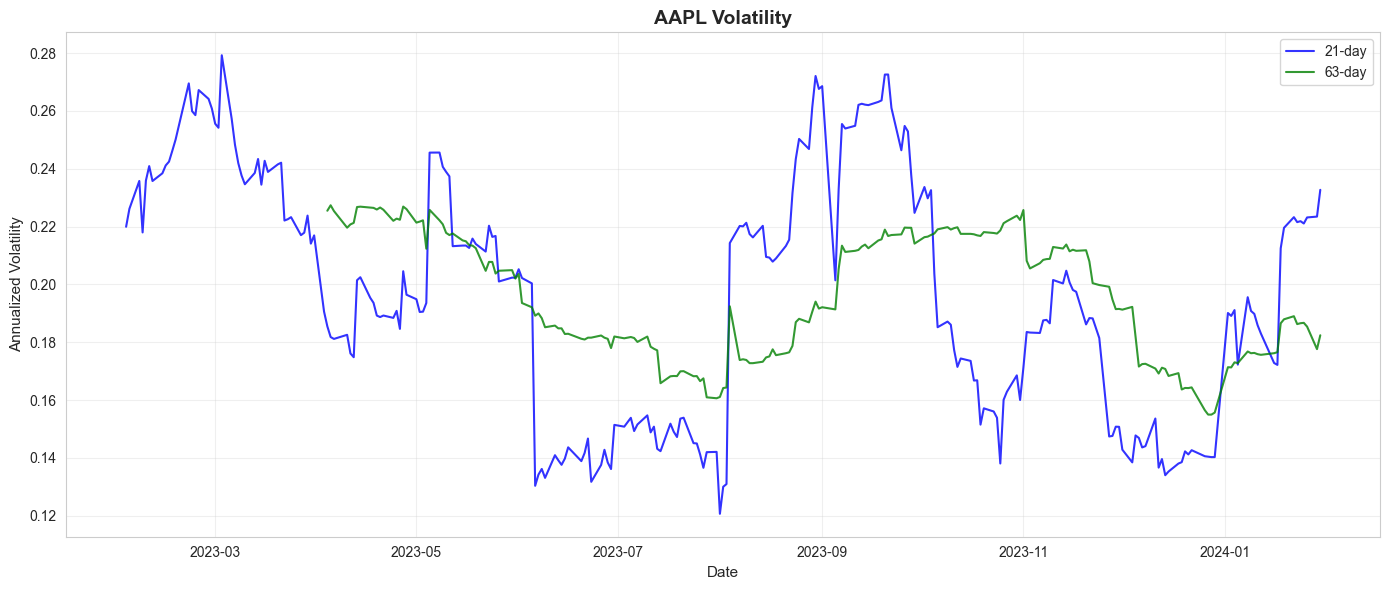

In [12]:
fig = viz.plot_volatility(log_returns, vol_windows=[21, 63], title=f'{ticker} Volatility')
plt.show()

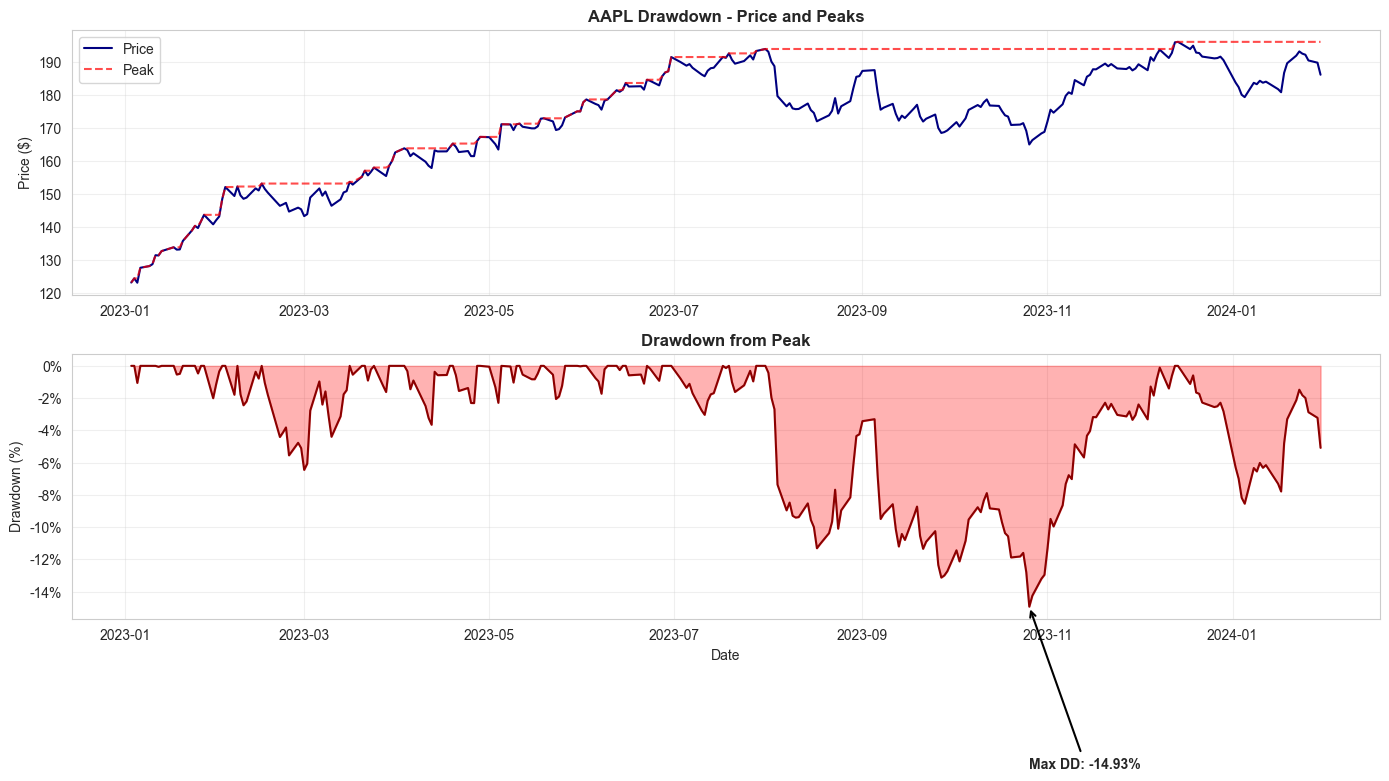

In [13]:
fig = viz.plot_drawdown(prices, title=f'{ticker} Drawdown')
plt.show()

In [14]:
# Compare 2 stocks
stocks = ['AAPL', 'MSFT']
results = {}

for t in stocks:
    d = yf.download(t, start='2023-01-01', end='2024-01-31', progress=False)
    
    # Flatten columns
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    
    p = d['Adj Close']
    r = rm.log_returns(p)
    
    results[t] = {
        'Total Return (%)': 100 * (p.iloc[-1] / p.iloc[0] - 1),
        'Sharpe': rm.sharpe_ratio(r),
        'Max DD (%)': 100 * rm.max_drawdown(p)
    }

comparison = pd.DataFrame(results).T
display(comparison.round(2))

KeyError: 'Adj Close'